# Cancer Prediction

**Cancer Prediction** is a binary classification task aimed at predicting whether a patient has cancer based on medical and lifestyle features.  
The dataset consists of information collected from **1,500 synthetic patient records**, designed to simulate realistic medical data for predictive modeling.

---

Dataset Description

Each record contains the following features:

- **Age:** Patient’s age (20–80 years)  
- **Gender:** 0 = Male, 1 = Female  
- **BMI:** Body Mass Index, ranging from 15 to 40  
- **Smoking:** 0 = No, 1 = Yes  
- **GeneticRisk:** 0 = Low, 1 = Medium, 2 = High  
- **PhysicalActivity:** Hours of physical activity per week (0–10)  
- **AlcoholIntake:** Alcohol units consumed per week (0–5)  
- **CancerHistory:** 0 = No, 1 = Yes (personal history of cancer)  
- **Diagnosis:** Target variable — 0 = No Cancer, 1 = Cancer
  
---

These features provide quantitative measurements that can be used to assess patient health and lifestyle factors associated with cancer risk. By training a machine learning model on this dataset, it is possible to develop a predictive model that can assist in identifying individuals at higher risk of cancer and support early detection and prevention efforts.

---

In [1]:
#importing the libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, f1_score, roc_auc_score, confusion_matrix, classification_report

In [2]:
#importing the dataset
df = pd.read_csv('../data/data.csv')
df.head()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


## Data Preprocessing Part 1

In [3]:
# Checking the shape of the dataset
df.shape

(1500, 9)

In [4]:
# Remove unused columns

In [5]:
# Check for duplicate
df.duplicated().sum()

np.int64(0)

In [6]:
#check data type and missing values
df.info()

print("\n\nMissing Values per Column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1500 non-null   int64  
 1   Gender            1500 non-null   int64  
 2   BMI               1500 non-null   float64
 3   Smoking           1500 non-null   int64  
 4   GeneticRisk       1500 non-null   int64  
 5   PhysicalActivity  1500 non-null   float64
 6   AlcoholIntake     1500 non-null   float64
 7   CancerHistory     1500 non-null   int64  
 8   Diagnosis         1500 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 105.6 KB


Missing Values per Column:
Age                 0
Gender              0
BMI                 0
Smoking             0
GeneticRisk         0
PhysicalActivity    0
AlcoholIntake       0
CancerHistory       0
Diagnosis           0
dtype: int64


In [7]:
#checking number of unique values in each column
df.nunique()

Age                   61
Gender                 2
BMI                 1500
Smoking                2
GeneticRisk            3
PhysicalActivity    1500
AlcoholIntake       1500
CancerHistory          2
Diagnosis              2
dtype: int64

In [8]:
#checking the unique values in each column
cols = df.columns
for i in cols:
    print(i, df[i].unique(), '\n')

Age [58 71 48 34 62 27 80 40 77 38 42 30 43 72 55 59 22 41 21 63 49 57 79 52
 31 44 68 46 78 61 47 35 66 70 74 76 56 26 28 37 23 33 69 45 39 54 36 25
 73 53 29 50 67 64 60 20 24 32 51 75 65] 

Gender [1 0] 

BMI [16.08531332 30.82878439 38.78508356 ... 32.6138607  25.56821592
 23.6631042 ] 

Smoking [0 1] 

GeneticRisk [1 2 0] 

PhysicalActivity [8.14625056 9.36163042 5.13517867 ... 0.4668482  7.79531682 2.52586007] 

AlcoholIntake [4.14821903 3.51968334 4.72836769 ... 0.15010113 1.98613765 2.85660008] 

CancerHistory [1 0] 

Diagnosis [1 0] 



In [9]:
df.describe()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,50.320000,0.490667,27.513321,0.269333,0.508667,4.897929,2.417987,0.144000,0.371333
std,17.640968,0.500080,7.230012,0.443761,0.678895,2.866162,1.419318,0.351207,0.483322
min,20.000000,0.000000,15.000291,0.000000,0.000000,0.002410,0.001215,0.000000,0.000000
25%,35.000000,0.000000,21.483134,0.000000,0.000000,2.434609,1.210598,0.000000,0.000000
50%,51.000000,0.000000,27.598494,0.000000,0.000000,4.834316,2.382971,0.000000,0.000000
75%,66.000000,1.000000,33.850837,1.000000,1.000000,7.409896,3.585624,0.000000,1.000000
max,80.000000,1.000000,39.958688,1.000000,2.000000,9.994607,4.987115,1.000000,1.000000


## Exploratory Data Analysis
In the exploratory data analysis, I will be visualizing the data to get a better understanding of the data and to see if there are any trends or pattern in the data. First I will begin with looking at the distribution of the data and then I will look at the relationship between the independent variables and the target variable.

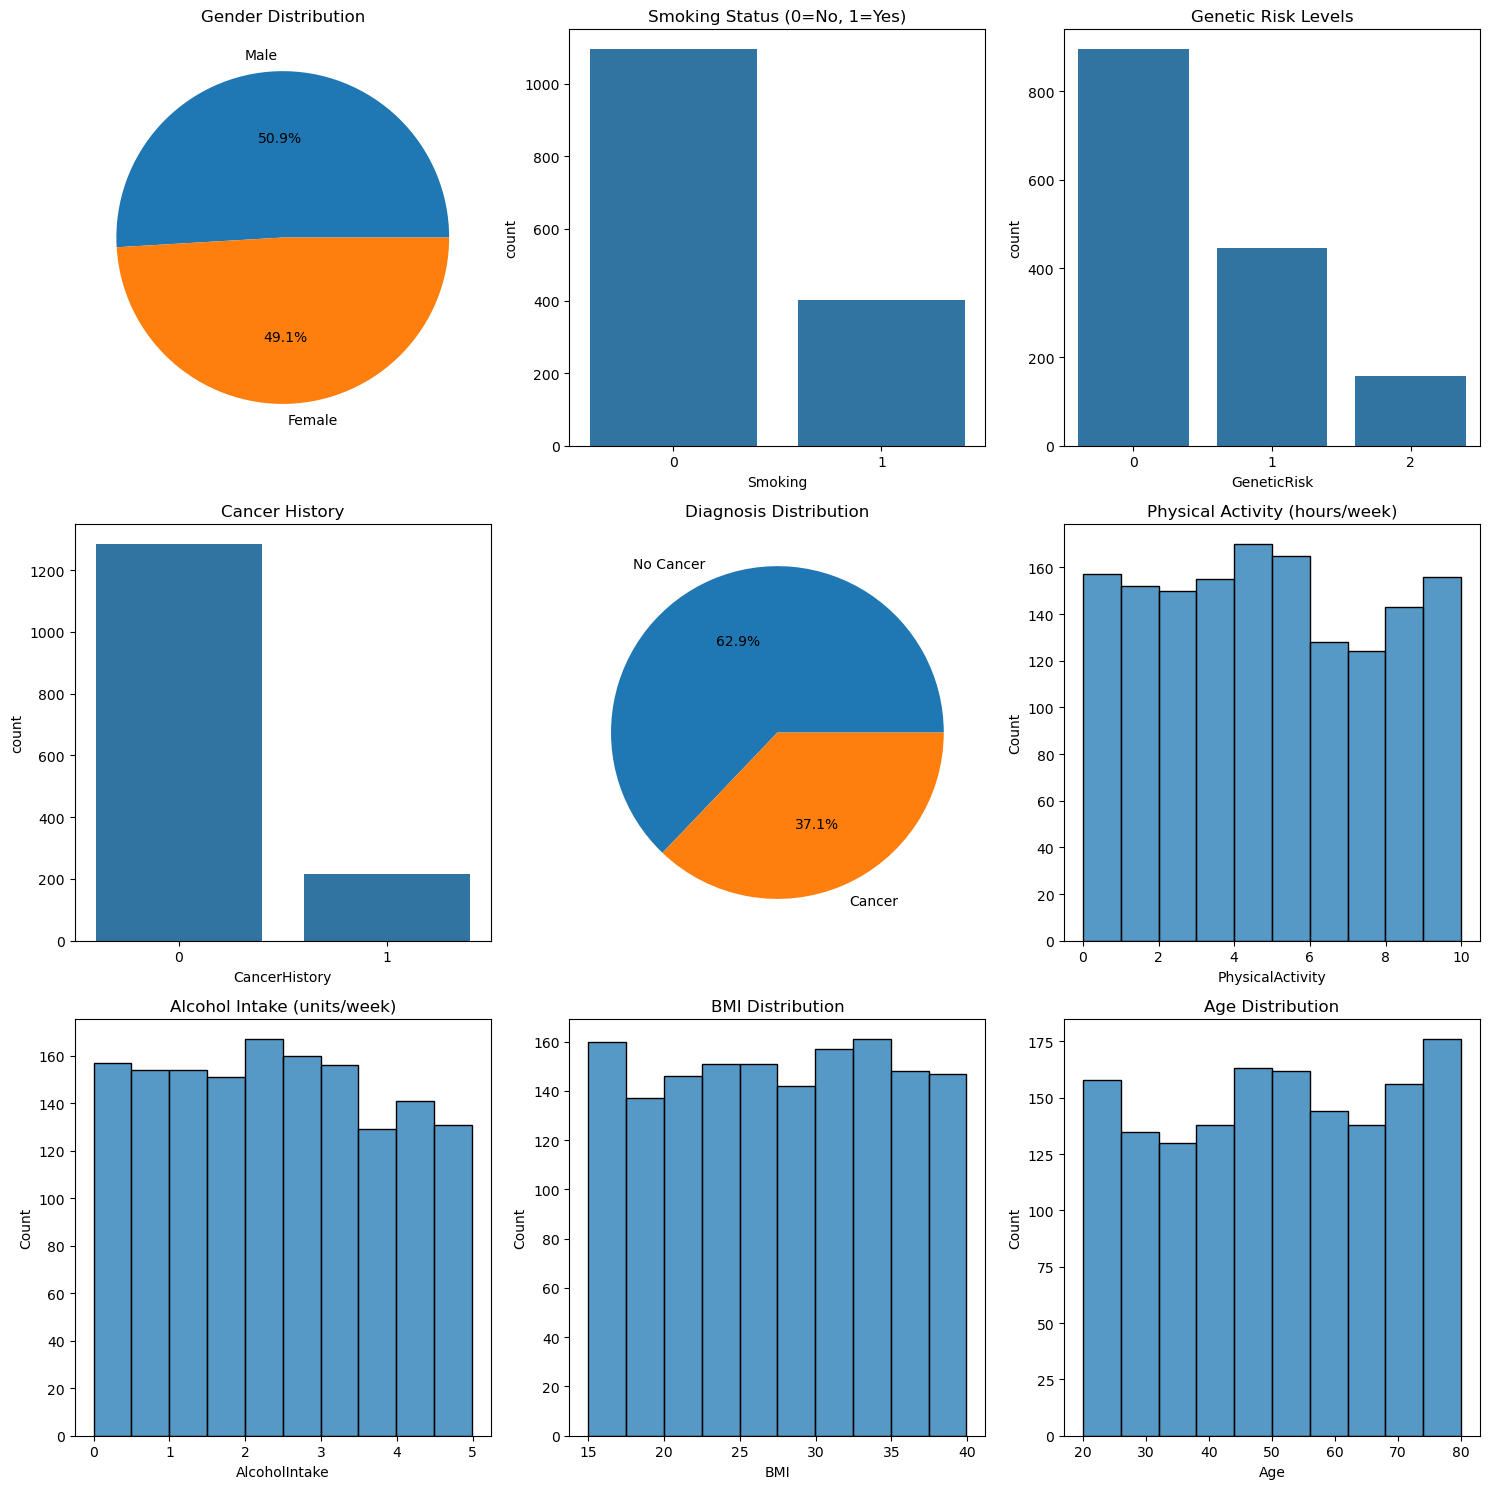

In [10]:
fig, ax = plt.subplots(3, 3, figsize=(15, 15))

# Gender Distribution
ax[0,0].pie(df['Gender'].value_counts(), labels=['Male', 'Female'], autopct='%1.1f%%')
ax[0,0].set_title('Gender Distribution')

# Smoking
sns.countplot(x='Smoking', data=df, ax=ax[0,1])
ax[0,1].set_title('Smoking Status (0=No, 1=Yes)')

# Genetic Risk
sns.countplot(x='GeneticRisk', data=df, ax=ax[0,2])
ax[0,2].set_title('Genetic Risk Levels')

# Cancer History
sns.countplot(x='CancerHistory', data=df, ax=ax[1,0])
ax[1,0].set_title('Cancer History')

# Diagnosis
ax[1,1].pie(df['Diagnosis'].value_counts(), labels=['No Cancer', 'Cancer'], autopct='%1.1f%%')
ax[1,1].set_title('Diagnosis Distribution')

# Physical Activity
sns.histplot(df['PhysicalActivity'], bins=10, ax=ax[1,2])
ax[1,2].set_title('Physical Activity (hours/week)')

# Alcohol Intake
sns.histplot(df['AlcoholIntake'], bins=10, ax=ax[2,0])
ax[2,0].set_title('Alcohol Intake (units/week)')

# BMI
sns.histplot(df['BMI'], bins=10, ax=ax[2,1])
ax[2,1].set_title('BMI Distribution')

# Age
sns.histplot(df['Age'], bins=10, ax=ax[2,2])
ax[2,2].set_title('Age Distribution')

plt.tight_layout()
plt.show()

These graphs visualize the distribution of demographic and lifestyle features among patients in the cancer prediction dataset.
The gender distribution is nearly balanced between male and female patients. Most patients are non-smokers, and only a small portion report a personal history of cancer.

Regarding genetic risk, the majority of patients fall into the low risk category, with fewer individuals in the medium and high risk levels.
The diagnosis distribution shows that around 37.1% of patients are diagnosed with cancer, indicating a reasonably balanced target variable suitable for model training.

Lifestyle-related factors such as physical activity, alcohol intake, BMI, and age appear to be uniformly distributed across the dataset, ensuring that the model can learn patterns across a wide range of health profiles.

Overall, the dataset presents a realistic and balanced mix of medical and lifestyle features, providing a solid foundation for developing a machine learning model to predict cancer presence.

## Data Preprocessing Part 2

### Outlier

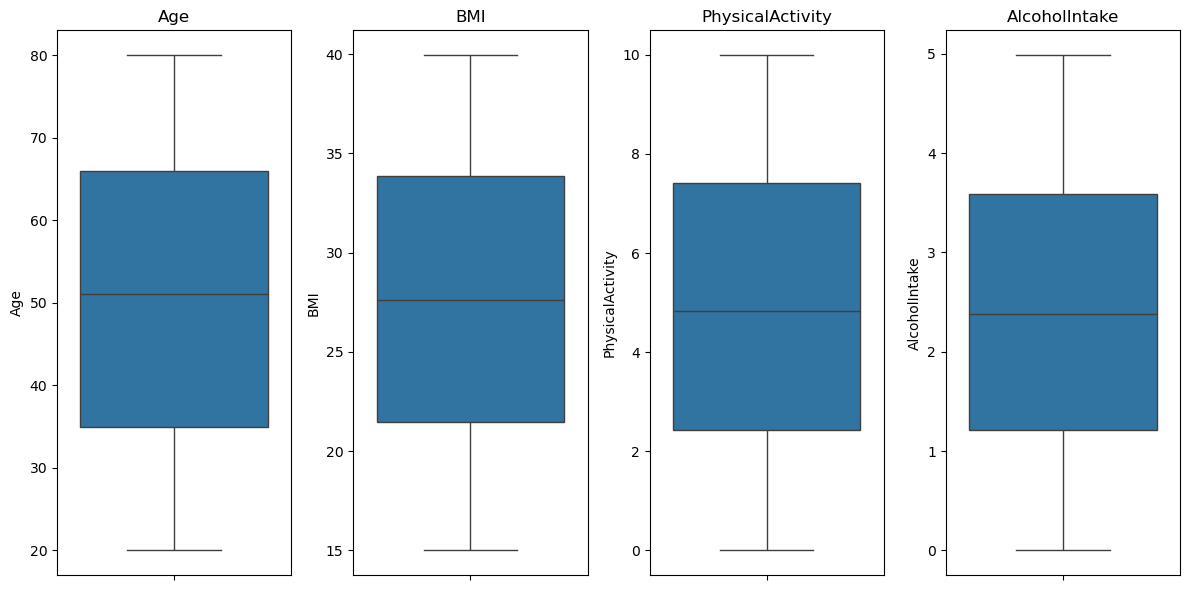

In [11]:
# Check for outlier
numeric_cols = ['Age', 'BMI', 'PhysicalActivity', 'AlcoholIntake']

plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### Feature Scaling

In [12]:
#Standardizing the data
sc = StandardScaler()
df[['Age', 'BMI', 'PhysicalActivity', 'AlcoholIntake']] = sc.fit_transform(df[['Age', 'BMI', 'PhysicalActivity', 'AlcoholIntake']])

### Correlation

<Axes: >

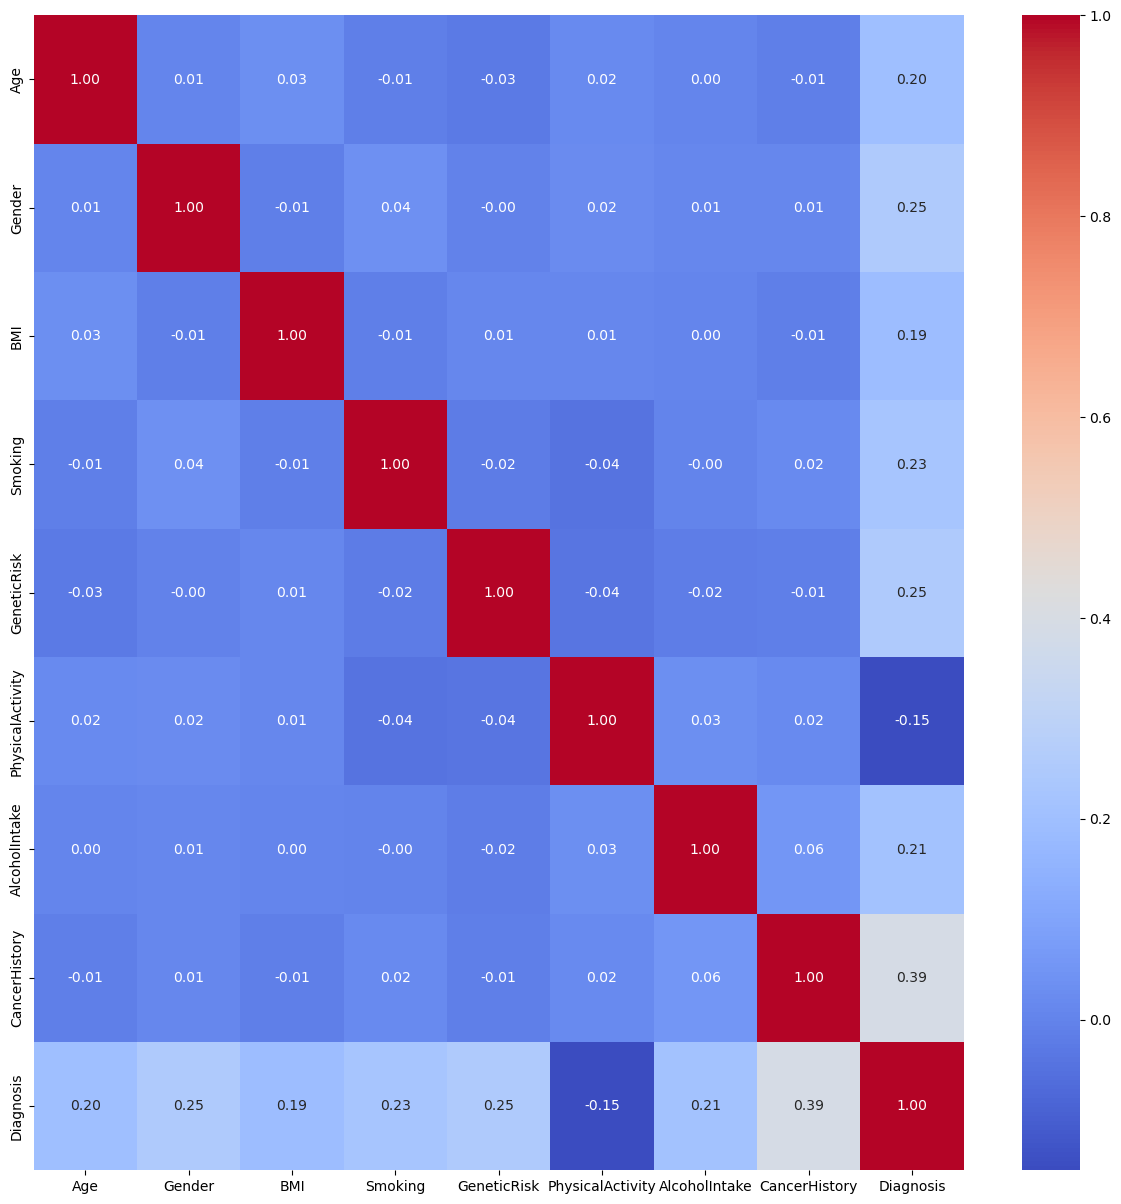

In [13]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

### Feature Correlation

Based on the correlation heatmap:
1. No multicollinearity was detected among features (all correlation values < 0.7).
2. CancerHistory shows the highest correlation with the target Diagnosis (0.39), followed by GeneticRisk (0.25), Smoking (0.23), and Age (0.20).
3. PhysicalActivity has a negative correlation (-0.15) with Diagnosis, indicating that higher activity levels are associated with a lower likelihood of cancer.

These findings will guide feature selection for the upcoming modeling phase.

### EDA Summary
Key findings from the exploratory data analysis:
1. No missing values were found in the dataset.
2. Features such as Gender, Smoking, CancerHistory, and Diagnosis are binary categorical.
3. GeneticRisk is an ordinal feature with three risk levels.
4. Numerical features (Age, BMI, PhysicalActivity, AlcoholIntake) show relatively uniform but non-normal distributions.
5. The strongest correlations with Diagnosis are observed for GeneticRisk and PhysicalActivity.
6. The target variable (Diagnosis) is slightly imbalanced and should be considered during model training.

## Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='Diagnosis'), df['Diagnosis'], test_size=0.2, random_state=42)

## Model Building
Following models to predict the cancer:
1. Logistic Regression Classifier
2. Random Forest Classifier
3. XGBoost Classifier

### Logistic Regression

In [15]:
# Logistic Regression Classifier Object with standard parameters
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Fitting the data
log_reg.fit(X_train, y_train)

# Predicting the values
y_pred = log_reg.predict(X_test)

Test Accuracy: 0.8600

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       184
           1       0.87      0.75      0.81       116

    accuracy                           0.86       300
   macro avg       0.86      0.84      0.85       300
weighted avg       0.86      0.86      0.86       300



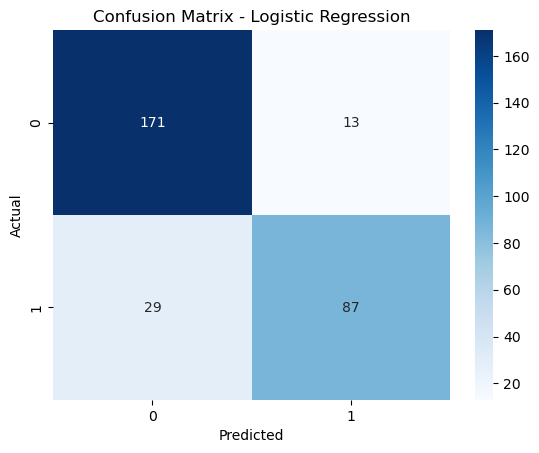

ROC-AUC Score: 0.9426


In [16]:
# Test accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc:.4f}')

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# ROC-AUC
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC Score: {roc_auc:.4f}')

### Random Forest Classifier

In [17]:
#Random Forest Classifier Object
rf = RandomForestClassifier()

### Hyperparameter Tuning using GridSearchCV

In [18]:
#parameter grid
param_grid = {
    'max_depth': [2,4,6,8,10],
    'min_samples_leaf': [2,4,6,8,10],
    'min_samples_split': [2,4,6,8,10],
    'criterion': ['gini', 'entropy'],
    'random_state': [0,42]
}

#Grid Search Object with Random Forest Classifier
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, cv = 3, n_jobs = -1, verbose = 2, scoring='roc_auc')

#Fitting the data
grid_search.fit(X_train, y_train)

#Best parameters
print(grid_search.best_params_)

Fitting 3 folds for each of 500 candidates, totalling 1500 fits
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'random_state': 0}


In [19]:
#Random Forest Classifier Object with best parameters
rf = RandomForestClassifier(
    criterion='entropy',       
    max_depth=10,
    min_samples_leaf=4,
    min_samples_split=2,
    random_state=0
)

# Latih model
rf.fit(X_train, y_train)

# Prediksi data test
y_pred_rf = rf.predict(X_test)

Test Accuracy (Random Forest): 0.9233

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       184
           1       0.94      0.85      0.90       116

    accuracy                           0.92       300
   macro avg       0.93      0.91      0.92       300
weighted avg       0.92      0.92      0.92       300



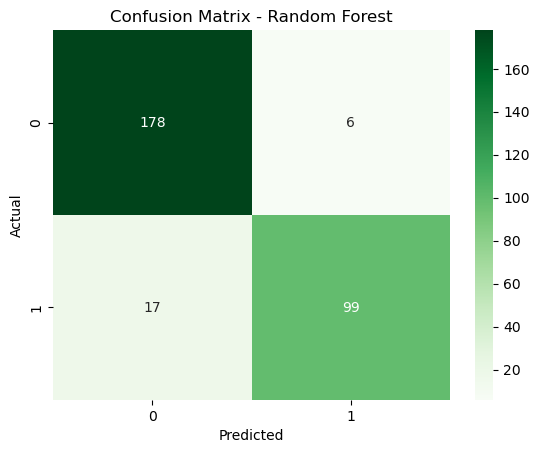

ROC-AUC Score (Random Forest): 0.9559


In [20]:
# Test accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Test Accuracy (Random Forest): {acc_rf:.4f}')

# Classification report
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC-AUC
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f'ROC-AUC Score (Random Forest): {roc_auc_rf:.4f}')

### XGBoost Classifier

In [21]:
# XGBoost Classifier Object
xgb = XGBClassifier()

### Hyperparameter Tuning using RandomizedSearchCV

In [22]:
# Parameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3]
}

# RandomizedSearch Object with XGBoost Classifier
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,                   
    scoring='roc_auc',           
    cv=5,                        
    verbose=1,
    random_state=42,
    n_jobs=-1                    
)

# Fitting the data
random_search.fit(X_train, y_train)

#Best parameters
print("Best Parameters:", random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}


### Fine Tuning using GridSearchCV

In [23]:
# Parameter grid
param_dist_search = {
    'n_estimators': [80, 100, 120, 150],
    'learning_rate': [0.05, 0.08, 0.1, 0.12, 0.15],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'gamma': [0, 0.05, 0.1, 0.2]
}

#Grid Search Object with Random Forest Classifier
grid_search = GridSearchCV(estimator = xgb, param_grid = param_dist_search, cv = 5, n_jobs = -1, verbose = 1, scoring='roc_auc')

#Fitting the data
grid_search.fit(X_train, y_train)

#Best parameters
print(grid_search.best_params_)

Fitting 5 folds for each of 3840 candidates, totalling 19200 fits
{'colsample_bytree': 0.6, 'gamma': 0.2, 'learning_rate': 0.12, 'max_depth': 2, 'n_estimators': 150, 'subsample': 0.9}


In [24]:
#XGBoost Classifier Object with best parameters
xgb = XGBClassifier(
    colsample_bytree=0.6,       
    gamma=0.2,
    learning_rate=0.12,
    max_depth=2,
    n_estimators=150,
    subsample=0.9
)

# Latih model
xgb.fit(X_train, y_train)

# Prediksi data test
y_pred_xgb = xgb.predict(X_test)

Test Accuracy (XGBoost): 0.9433

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       184
           1       0.96      0.89      0.92       116

    accuracy                           0.94       300
   macro avg       0.95      0.93      0.94       300
weighted avg       0.94      0.94      0.94       300



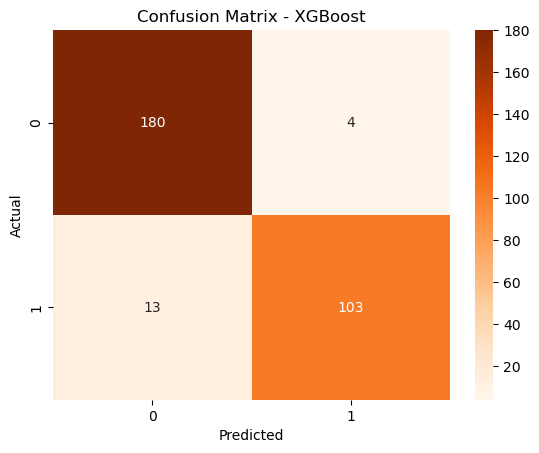

ROC-AUC Score (XGBoost): 0.9666


In [25]:
# Test accuracy
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'Test Accuracy (XGBoost): {acc_xgb:.4f}')

# Classification report
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC-AUC
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f'ROC-AUC Score (XGBoost): {roc_auc_xgb:.4f}')

## Model Evaluation

### Confusion Matrix Heatmap

Text(0.5, 1.0, 'XGBoost Confusion Matrix')

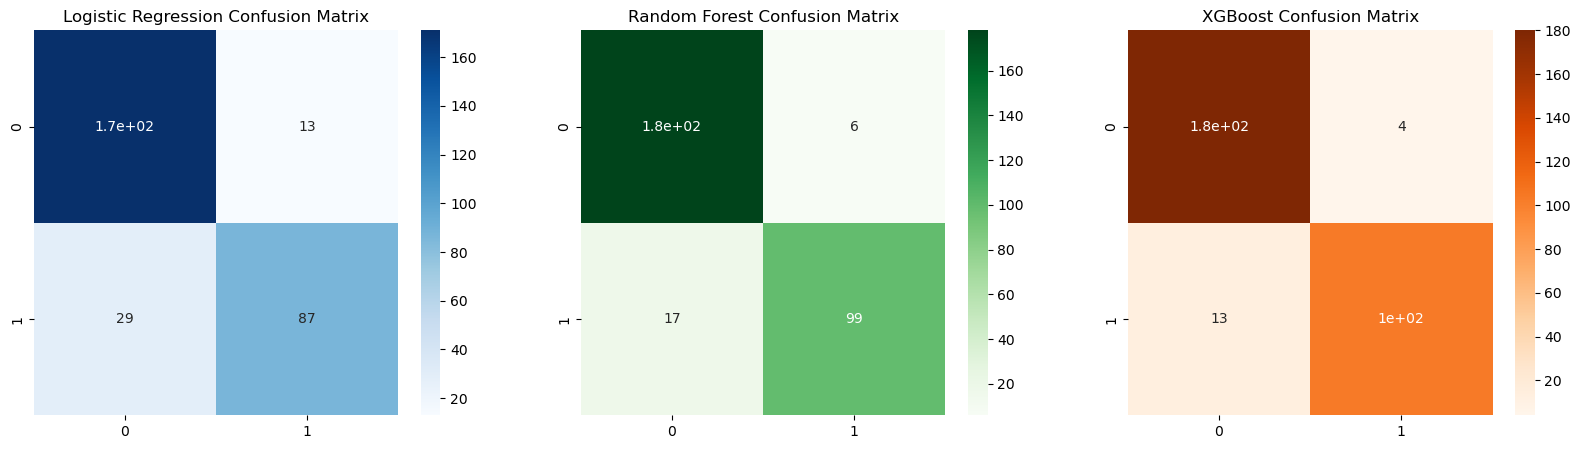

In [26]:
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

#Logistic Regression Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, ax=ax[0], cmap='Blues').set_title('Logistic Regression Confusion Matrix')

#Random Forest Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, ax=ax[1], cmap='Greens').set_title('Random Forest Confusion Matrix')

#XGBoost Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, ax=ax[2], cmap='Oranges').set_title('XGBoost Confusion Matrix')

The confusion matrix heatmaps visualize the true positive and true negative predictions for each model. From the comparison, it can be observed that the XGBoost Classifier achieved the highest number of correctly classified samples, with fewer false positives and false negatives compared to Logistic Regression and Random Forest. The Random Forest Classifier also performed well, showing strong predictive capability, while Logistic Regression had slightly higher misclassification counts.

Therefore, based on the confusion matrix analysis, the XGBoost Classifier demonstrates the best overall performance in accurately predicting cancer diagnosis, making it the most effective model among the three.

## Probability Distribution Plot

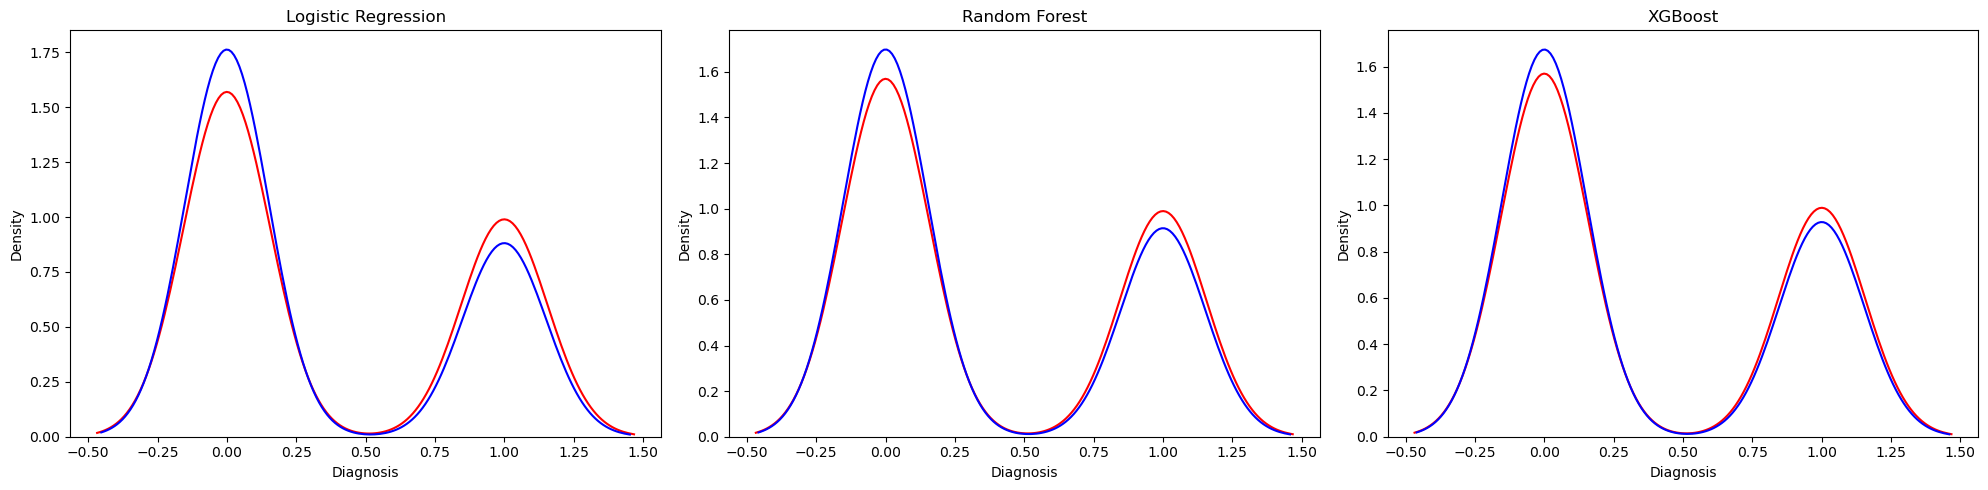

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Logistic Regression
sns.kdeplot(y_test, color="r", label="Actual Value", ax=ax[0])
sns.kdeplot(y_pred, color="b", label="Fitted Values", ax=ax[0])
ax[0].set_title('Logistic Regression')
ax[0].set_xlabel('Diagnosis')
ax[0].set_ylabel('Density')

# Random Forest
sns.kdeplot(y_test, color="r", label="Actual Value", ax=ax[1])
sns.kdeplot(y_pred_rf, color="b", label="Fitted Values", ax=ax[1])
ax[1].set_title('Random Forest')
ax[1].set_xlabel('Diagnosis')
ax[1].set_ylabel('Density')

# XGBoost
sns.kdeplot(y_test, color="r", label="Actual Value", ax=ax[2])
sns.kdeplot(y_pred_xgb, color="b", label="Fitted Values", ax=ax[2])
ax[2].set_title('XGBoost')
ax[2].set_xlabel('Diagnosis')
ax[2].set_ylabel('Density')

plt.tight_layout()
plt.show()

### Classification Report

In [28]:
# Logistic Regression
report_lr = classification_report(y_test, y_pred, output_dict=True)
df_lr = pd.DataFrame(report_lr).transpose()

# Random Forest
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
df_rf = pd.DataFrame(report_rf).transpose()

# XGBoost
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
df_xgb = pd.DataFrame(report_xgb).transpose()

print("Logistic Regression Report")
display(df_lr.round(3))

print("\nRandom Forest Report")
display(df_rf.round(3))

print("\nXGBoost Report")
display(df_xgb.round(3))

Logistic Regression Report


,precision,recall,f1-score,support
0,0.855,0.929,0.891,184.00
1,0.870,0.750,0.806,116.00
accuracy,0.860,0.860,0.860,0.86
macro avg,0.862,0.840,0.848,300.00
weighted avg,0.861,0.860,0.858,300.00



Random Forest Report


,precision,recall,f1-score,support
0,0.913,0.967,0.939,184.000
1,0.943,0.853,0.896,116.000
accuracy,0.923,0.923,0.923,0.923
macro avg,0.928,0.910,0.918,300.000
weighted avg,0.924,0.923,0.923,300.000



XGBoost Report


,precision,recall,f1-score,support
0,0.933,0.978,0.955,184.000
1,0.963,0.888,0.924,116.000
accuracy,0.943,0.943,0.943,0.943
macro avg,0.948,0.933,0.939,300.000
weighted avg,0.944,0.943,0.943,300.000


### Model Metrics

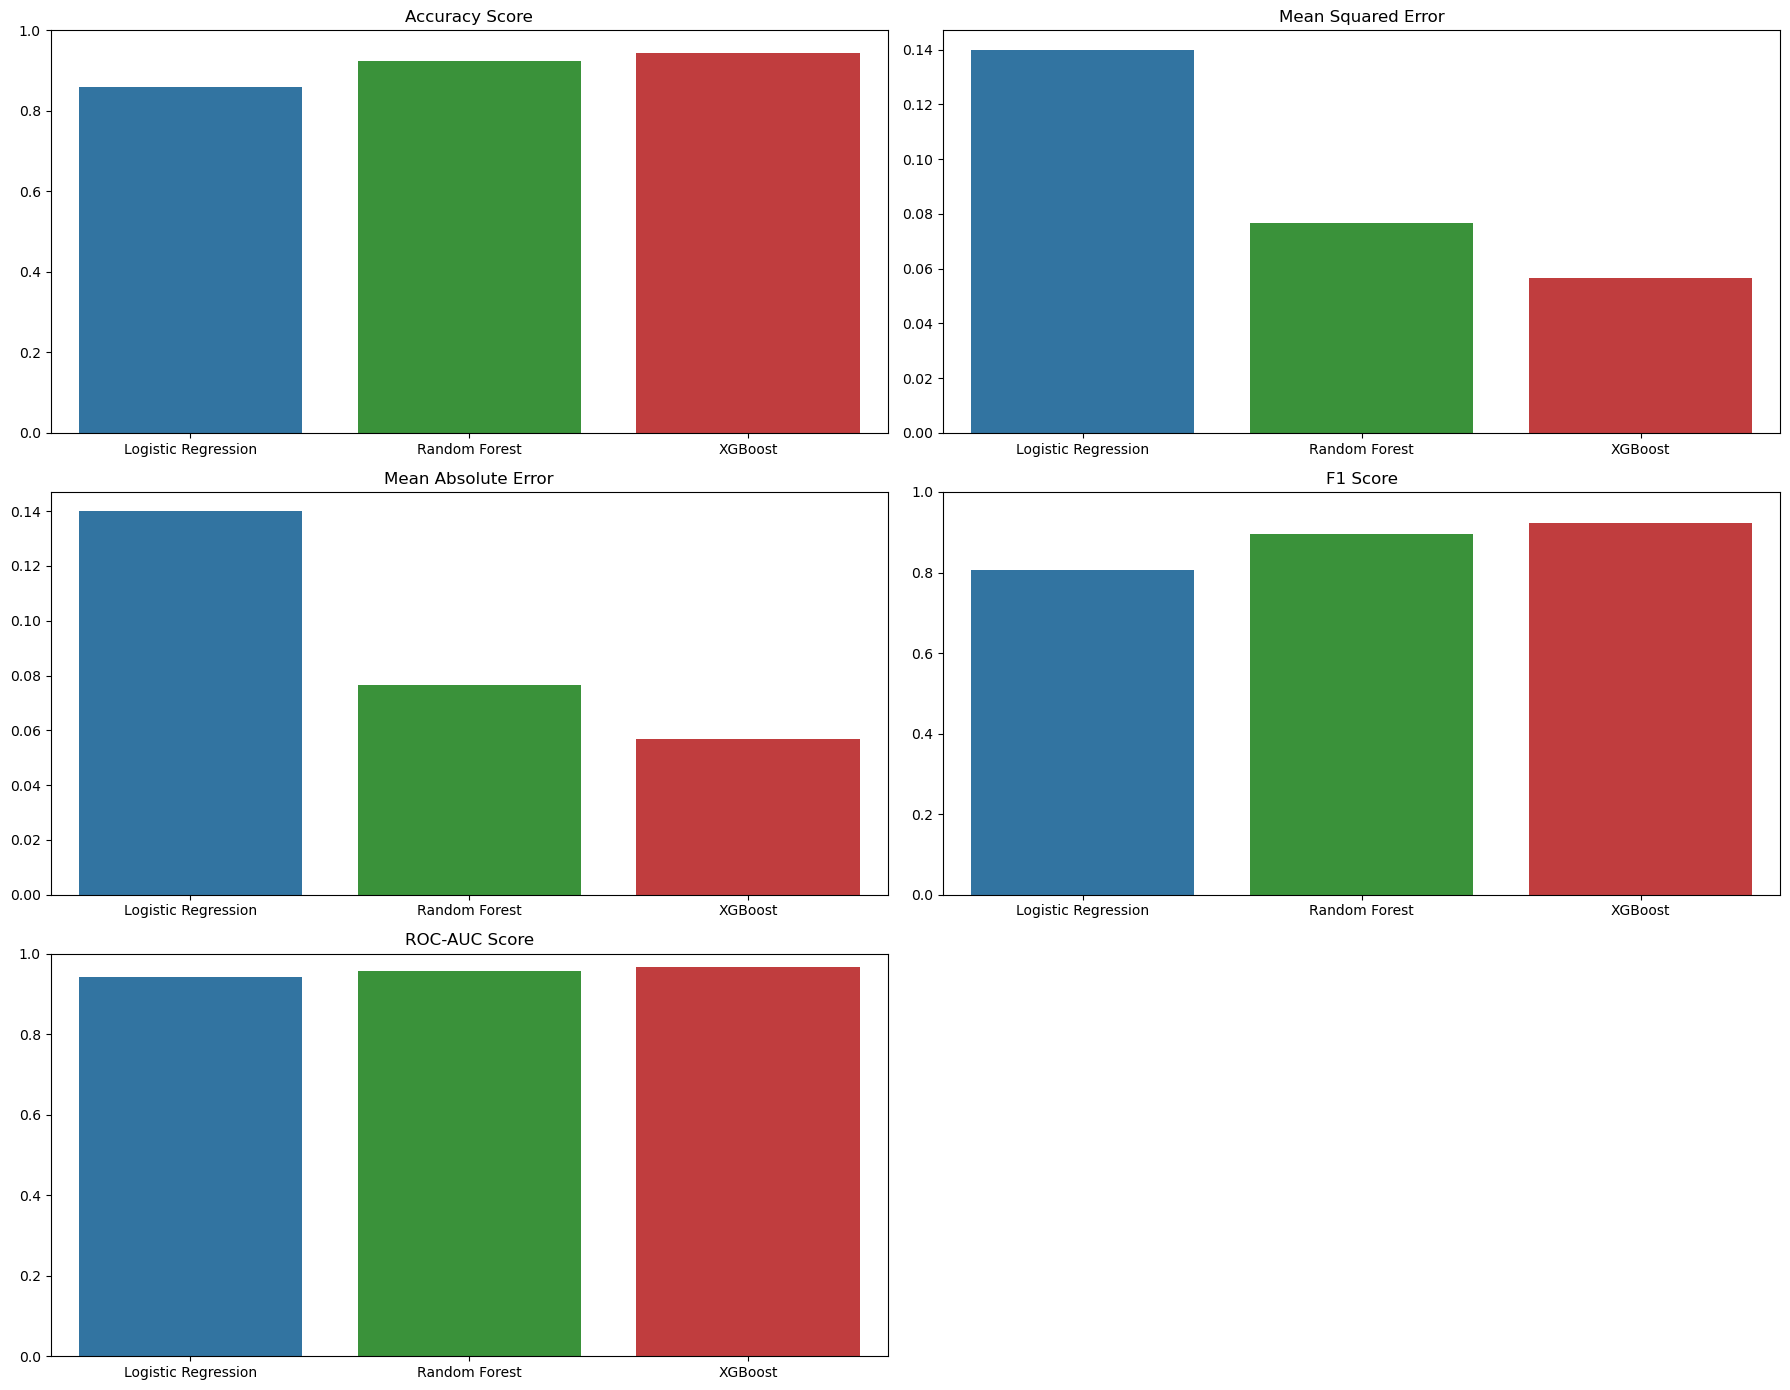

In [29]:
# Bar plots
fig, ax = plt.subplots(3, 2, figsize=(18, 14))

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
palette = ["#1f77b4", "#2ca02c", "#d62728"]

# Accuracy Score
sns.barplot(
    x=models,
    y=[
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    ax=ax[0, 0],
    hue=models,
    palette=palette
)
ax[0, 0].set_title('Accuracy Score')
ax[0, 0].set_ylim(0, 1)

# Mean Squared Error
sns.barplot(
    x=models,
    y=[
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_xgb)
    ],
    ax=ax[0, 1],
    hue=models,
    palette=palette
)
ax[0, 1].set_title('Mean Squared Error')

# Mean Absolute Error
sns.barplot(
    x=models,
    y=[
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    ax=ax[1, 0],
    hue=models,
    palette=palette
)
ax[1, 0].set_title('Mean Absolute Error')

# F1 Score
sns.barplot(
    x=models,
    y=[
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    ax=ax[1, 1],
    hue=models,
    palette=palette
)
ax[1, 1].set_title('F1 Score')
ax[1, 1].set_ylim(0, 1)

# ROC-AUC Score
sns.barplot(
    x=models,
    y=[
        roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])
    ],
    ax=ax[2, 0],
    hue=models,
    palette=palette
)
ax[2, 0].set_title('ROC-AUC Score')
ax[2, 0].set_ylim(0, 1)

ax[2, 1].axis('off')

# Layout
plt.tight_layout()
plt.show()

These graphs compares the models based on the metrics such as accuracy score, mean squared error, mean absolute error, f1 score, and ROC-AUC Score. The XGBoost Classifier has the highest accuracy score and F1 Score, and lowest mean squared error, mean absolute error. Therefore, the Random Forest Classifier is a good fit for predicting the cancer.

## Feature Importance

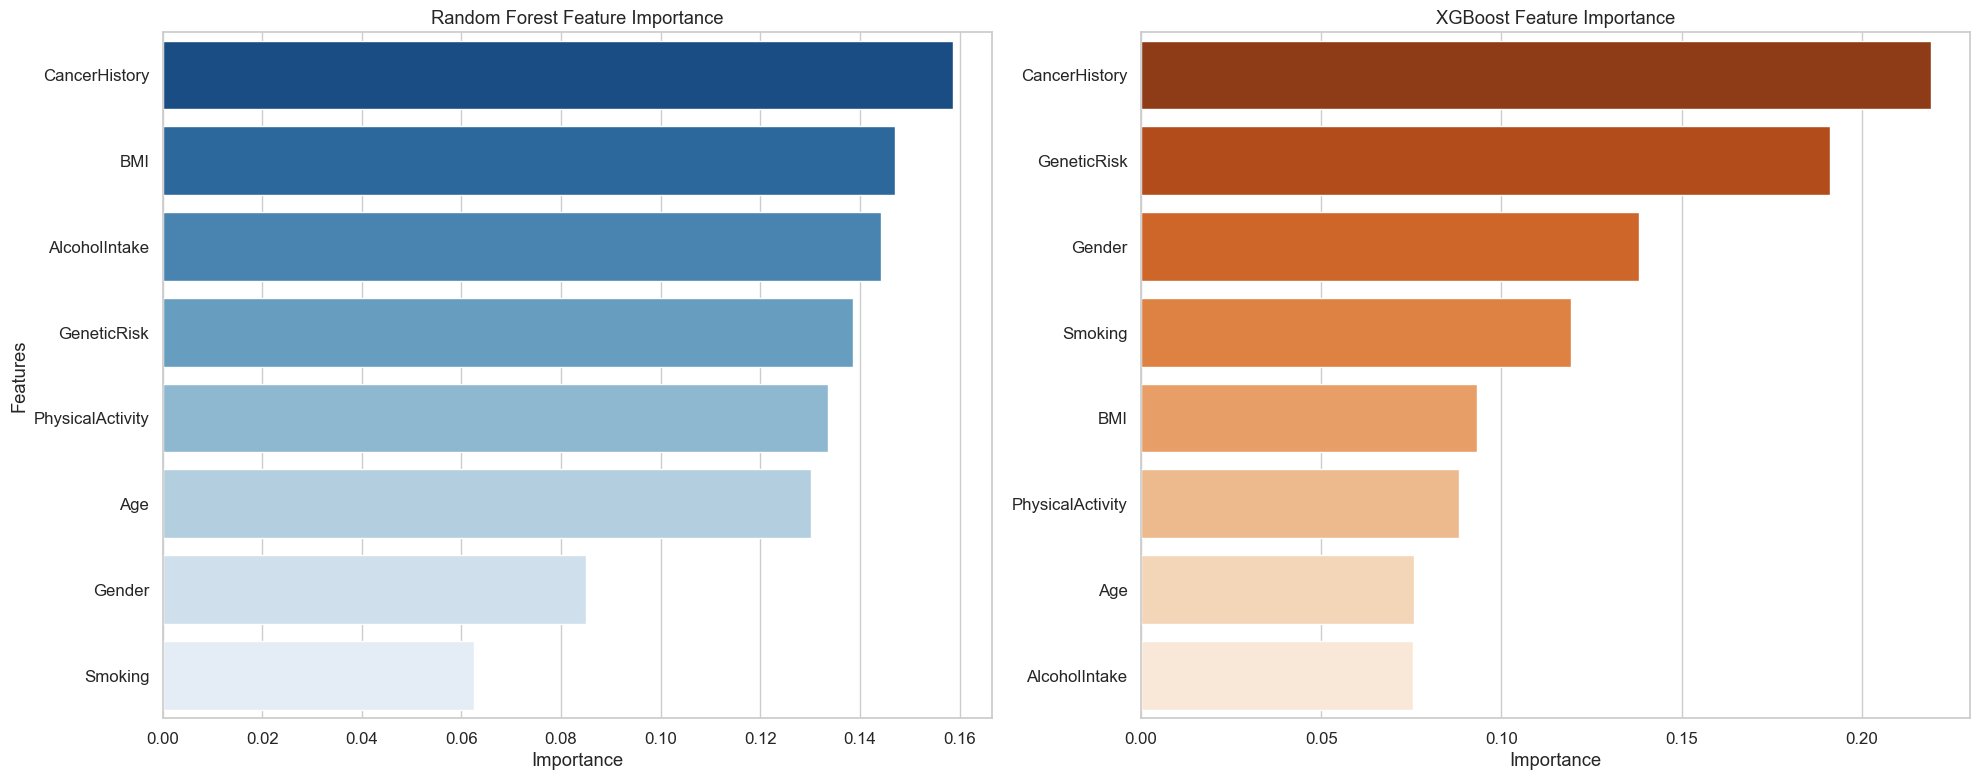

In [30]:
# Setup style
sns.set(style="whitegrid", font_scale=1.1)

fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# Random Forest Feature Importance 
rf_features = pd.DataFrame({
    'Features': X_train.columns,
    'Importance': rf.feature_importances_
})
rf_features.sort_values('Importance', ascending=False, inplace=True)

sns.barplot(
    x='Importance',
    y='Features',
    data=rf_features,
    palette="Blues_r",
    hue='Features',
    legend=False,
    ax=ax[0]
)
ax[0].set_title('Random Forest Feature Importance')
ax[0].set_xlabel('Importance')
ax[0].set_ylabel('Features')

# XGBoost Feature Importance 
xgb_features = pd.DataFrame({
    'Features': X_train.columns,
    'Importance': xgb.feature_importances_
})
xgb_features.sort_values('Importance', ascending=False, inplace=True)

sns.barplot(
    x='Importance',
    y='Features',
    data=xgb_features,
    palette="Oranges_r",
    hue='Features',
    legend=False,
    ax=ax[1]
)
ax[1].set_title('XGBoost Feature Importance')
ax[1].set_xlabel('Importance')
ax[1].set_ylabel('')

# Layout
plt.tight_layout()
plt.show()

Based on feature importance from both Random Forest and XGBoost models, CancerHistory is the most dominant factor influencing cancer prediction.
While other features vary slightly between models, factors such as GeneticRisk, BMI, and lifestyle-related attributes (Smoking, AlcoholIntake) also contribute meaningfully.
This suggests that a patient’s medical background, genetic predisposition, and lifestyle habits collectively play key roles in predicting cancer likelihood.

### Conclusion

From the exploratory data analysis, it was observed that the dataset is clean with no missing values and shows balanced class distribution. The correlation analysis indicates that there is no multicollinearity among the features, as all correlation values are below 0.7. The feature CancerHistory shows the strongest positive correlation with the target variable Diagnosis (0.39), followed by GeneticRisk (0.25), Smoking (0.23), and Age (0.20). Meanwhile, PhysicalActivity has a weak negative correlation (-0.15) with Diagnosis, suggesting that patients with higher physical activity levels tend to have a lower risk of cancer.

From the feature importance analysis of both Random Forest and XGBoost models, it is evident that CancerHistory is the most influential feature in predicting cancer diagnosis. Other significant features include GeneticRisk, BMI, Smoking, and AlcoholIntake, which also contribute notably to the model’s predictions. These findings suggest that medical history, genetic predisposition, and lifestyle factors collectively play an important role in determining cancer likelihood.

In the modeling phase, three classification algorithms were implemented Logistic Regression, Random Forest, and XGBoost. Among them, XGBoost Classifier achieved the highest performance with an accuracy of 94.3%, followed by Random Forest at 92.3%, and Logistic Regression at 86%. XGBoost also demonstrated the highest F1-Score and ROC-AUC value, indicating its superior capability in distinguishing between cancer and non-cancer cases. Therefore, XGBoost is identified as the most suitable model for cancer prediction in this project.